# Mathematics for Data Science (COM7023) Assessment
Performing investigations: using advanced mathematical techniques on a real-world data analytics problem for Urban Resource Intelligence.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sp
import scipy.stats as stats

plt.style.use('default')

## Question 1: Linear Algebra
The system of equations can be expressed in the form `Ax=b` (where A is the coefficient matrix, x for the variables, and b for the independent terms) and will be solved as follows:

In [3]:
# 1. calculation
A = np.array([
    [2, -1, 1, 0],
    [-1, 3, 0, -1],
    [1, 1, 2, -1],
    [0, -1, 1, 2]
], dtype=float)

b = np.array([120, 150, 180, 140], dtype=float)

x = np.linalg.solve(A, b)
result = [round(i, 2) for i in x]
print(f"""Result:
  x1 = {result[0]}
  x2 = {result[1]}
  x3 = {result[2]}
  x4 = {result[3]}""")

# 2. uniqueness check
det = np.linalg.det(A)
print(f'Det(A) = {det}')

Result:
  x1 = 105.0
  x2 = 123.33
  x3 = 33.33
  x4 = 115.0
Det(A) = 12.0


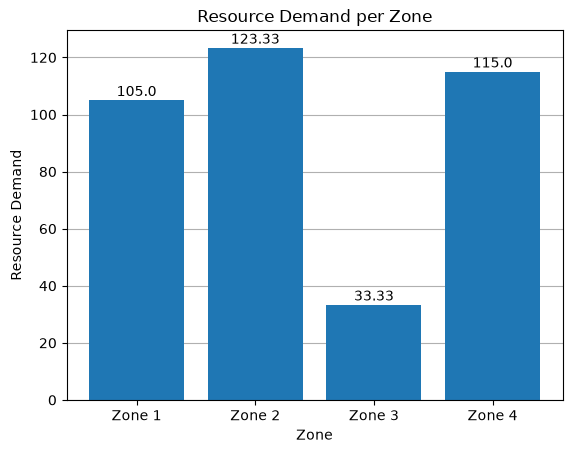

In [4]:
# 3. visualization
x = np.array(["Zone 1", "Zone 2", "Zone 3", "Zone 4"])
y = result
plt.bar(x, y,)
for i in range(len(x)):
    plt.text(x[i], y[i] + 1.5, str(y[i]), ha='center')
plt.xlabel("Zone")
plt.ylabel("Resource Demand")
plt.title("Resource Demand per Zone")
plt.grid(axis='y')
plt.gca().set_axisbelow(True)
plt.show()

## Question 2: Calculus
Analysis of demand over time within a high-density residential area. The rate of demand is modeled as a cubic function such that it should be analyzed:
- to examine rates of change
- to identify periods of rapid increase or decrease
- to determine any critical points
- to determine how the analysis supports peak-demand management

In [5]:
t = sp.symbols('t')
d = 4*t**3 - 18*t**2 + 24*t + 90
print('Demand function:')
sp.pprint(d)

d1 = sp.diff(d, t)
print('\nFirst derivative:')
sp.pprint(d1)

print('\nFactorized first derivative:')
sp.pprint(sp.factor(d1))

critical_points = sp.solve(d1, t)
print('\nCritical points:', critical_points)

d2 = sp.diff(d1, t)
print('\nSecond derivative:')
sp.pprint(d2)

print('\nSecond derivative test:')
for point in critical_points:
    print(f"D''({point}) =", d2.subs(t, point))

print("\nDemand at Critical Points:")
for point in critical_points:
    print(f"D({point}) =", d.subs(t, point))

print("\nBaseline Demand:\n")
print("D(0) =", d.subs(t, 0))

for item in [d, d1, d2]:
    print(item)

Demand function:
   3       2            
4⋅t  - 18⋅t  + 24⋅t + 90

First derivative:
    2            
12⋅t  - 36⋅t + 24

Factorized first derivative:
12⋅(t - 2)⋅(t - 1)

Critical points: [1, 2]

Second derivative:
24⋅t - 36

Second derivative test:
D''(1) = -12
D''(2) = 12

Demand at Critical Points:
D(1) = 100
D(2) = 98

Baseline Demand:

D(0) = 90
4*t**3 - 18*t**2 + 24*t + 90
12*t**2 - 36*t + 24
24*t - 36


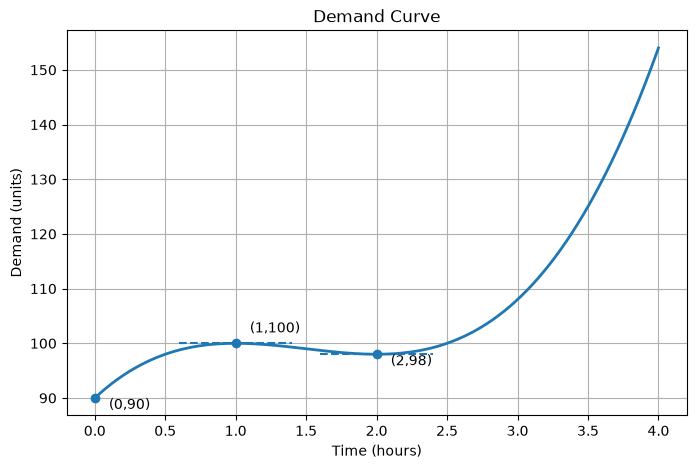

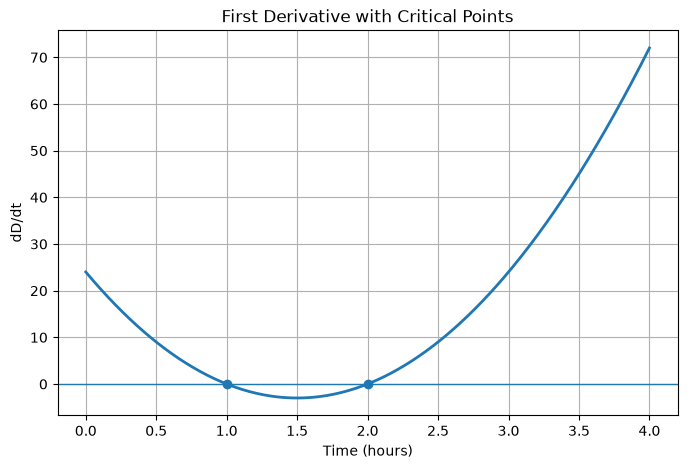

In [6]:
# Time values
t = np.linspace(0, 4, 400)

# Functions
D = 4*t**3 - 18*t**2 + 24*t + 90
D1 = 12*t**2 - 36*t + 24
D2 = 24*t - 36

# Critical points
critical_t = np.array([0, 1, 2])
critical_D = 4*critical_t**3 - 18*critical_t**2 + 24*critical_t + 90

# demand function
plt.figure(figsize=(8,5))
plt.plot(t, D, linewidth=2)
plt.scatter(critical_t, critical_D, zorder=3)
plt.hlines(100, 0.6, 1.4, linestyles='dashed')
plt.hlines(98, 1.6, 2.4, linestyles='dashed')
plt.annotate("(1,100)", (1,100), xytext=(1.1,102))
plt.annotate("(2,98)", (2,98), xytext=(2.1,96))
plt.annotate("(0,90)", (0,90), xytext=(0.1,88))
plt.xlabel("Time (hours)")
plt.ylabel("Demand (units)")
plt.title("Demand Curve")
plt.grid(True)
plt.show()

# first derivative with critical points
plt.figure(figsize=(8,5))
plt.plot(t, D1, linewidth=2)
plt.axhline(0, linewidth=1)
plt.scatter([1,2],[0,0], zorder=3)
plt.xlabel("Time (hours)")
plt.ylabel("dD/dt")
plt.title("First Derivative with Critical Points")
plt.grid(True)
plt.show()

# Question 3: Probability

In [7]:
mu, sigma = 0, 5
thresholds = [5, 10, 15]

print(f"{'x (units)':>10} | {'z':>4} | {'Phi(z)':>8} | {'P(E>x)':>8} | {'P(|E|>x)':>10}")
for x in thresholds:
    z = x / sigma
    phi = stats.norm.cdf(z)
    one_tail = 1 - phi
    two_tail = 2 * one_tail
    print(f"{x:>10} | {z:>4.1f} | {phi:>8.4f} | {one_tail:>8.4f} | {two_tail:>10.4f}")


 x (units) |    z |   Phi(z) |   P(E>x) |   P(|E|>x)
         5 |  1.0 |   0.8413 |   0.1587 |     0.3173
        10 |  2.0 |   0.9772 |   0.0228 |     0.0455
        15 |  3.0 |   0.9987 |   0.0013 |     0.0027


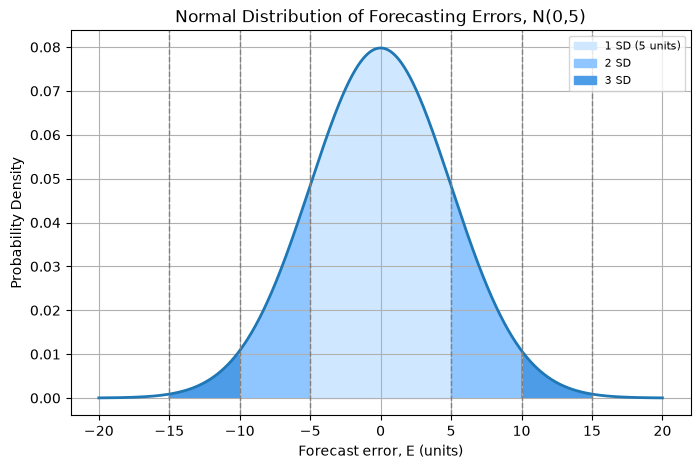

In [8]:
x = np.linspace(-20, 20, 1000)
pdf = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(8,5))
plt.plot(x, pdf, linewidth=2, color='tab:blue')

plt.fill_between(x, pdf, where=(x>=-5)&(x<=5), color='#cfe8ff', label='1 SD (5 units)')
plt.fill_between(x, pdf, where=((x>5)&(x<=10))|((x<-5)&(x>=-10)), color='#8fc6ff', label='2 SD')
plt.fill_between(x, pdf, where=((x>10)&(x<=15))|((x<-10)&(x>=-15)), color='#4c9ce8', label='3 SD')

for k in [5,10,15]:
    plt.axvline(k, linestyle='dashed', color='grey', linewidth=1)
    plt.axvline(-k, linestyle='dashed', color='grey', linewidth=1)

plt.xlabel("Forecast error, E (units)")
plt.ylabel("Probability Density")
plt.title("Normal Distribution of Forecasting Errors, N(0,5)")
plt.legend(fontsize=8, loc='upper right')
plt.grid(True)
plt.show()


#Question 4: Statistics

In [9]:
# 1. Data
apartments = np.array([16.8, 17.2, 16.5, 17.9, 18.1, 17.4, 16.9, 17.6])
terraced   = np.array([18.4, 18.9, 19.1, 18.7, 19.3, 18.6, 19.0, 18.8, 19.2, 18.5])
detached   = np.array([20.1, 19.7, 20.4, 19.9, 20.6, 20.2])

groups = [apartments, terraced, detached]
labels = ["Apartments", "Terraced", "Detached"]

# 2. Descriptive statistics
means = [g.mean() for g in groups]
ns = [len(g) for g in groups]
grand_mean = np.concatenate(groups).mean()

for lab, g, m in zip(labels, groups, means):
    print(f"{lab}: n={len(g)}, mean={m:.4f}, sd={g.std(ddof=1):.4f}")
print(f"\nGrand mean = {grand_mean:.4f}")

Apartments: n=8, mean=17.3000, sd=0.5555
Terraced: n=10, mean=18.8500, sd=0.3028
Detached: n=6, mean=20.1500, sd=0.3271

Grand mean = 18.6583


In [10]:
# 3. One-way ANOVA - verification of manual calculation
F_stat, p_value = stats.f_oneway(apartments, terraced, detached)
print(f"F statistic = {F_stat:.4f}")
print(f"p-value     = {p_value:.6e}")

# 4. Manual breakdown: SSB, SSW, df, MSB, MSW, F
ssb = sum(len(g) * (m - grand_mean)**2 for g, m in zip(groups, means))
ssw = sum(((g - m)**2).sum() for g, m in zip(groups, means))
sst = ssb + ssw

df_between = len(groups) - 1
df_within = len(np.concatenate(groups)) - len(groups)

msb = ssb / df_between
msw = ssw / df_within
F_manual = msb / msw

f_crit = stats.f.ppf(0.95, df_between, df_within)
eta_sq = ssb / sst

print(f"\nSSB={ssb:.4f}, SSW={ssw:.4f}, SST={sst:.4f}")
print(f"df_between={df_between}, df_within={df_within}")
print(f"MSB={msb:.4f}, MSW={msw:.4f}")
print(f"F (manual) = {F_manual:.4f}")
print(f"F critical (alpha=0.05) = {f_crit:.4f}")
print(f"eta^2 (effect size) = {eta_sq:.4f}")


F statistic = 84.9496
p-value     = 8.607176e-11

SSB=28.4783, SSW=3.5200, SST=31.9983
df_between=2, df_within=21
MSB=14.2392, MSW=0.1676
F (manual) = 84.9496
F critical (alpha=0.05) = 3.4668
eta^2 (effect size) = 0.8900


In [11]:
# Assumption checks
print("Shapiro-Wilk normality test (per group):")
for lab, g in zip(labels, groups):
    stat, p = stats.shapiro(g)
    print(f"  {lab}: W={stat:.4f}, p={p:.4f}")

print("\nLevene's test for homogeneity of variance (all 3 groups):")
stat, p = stats.levene(*groups)
print(f"  Levene statistic={stat:.4f}, p={p:.4f}")

# Welch's ANOVA - robust to unequal variances and unequal sample sizes
ns = np.array([len(g) for g in groups])
grp_means = np.array([g.mean() for g in groups])
grp_vars = np.array([g.var(ddof=1) for g in groups])
k = len(groups)

w = ns / grp_vars
sum_w = w.sum()
weighted_grand_mean = (w*grp_means).sum() / sum_w

numerator = (w*(grp_means-weighted_grand_mean)**2).sum() / (k-1)
term = ((1-w/sum_w)**2/(ns-1)).sum()
denominator = 1 + (2*(k-2)/(k**2-1))*term

F_welch = numerator/denominator
df1_welch = k-1
df2_welch = (k**2-1)/(3*term)
p_welch = 1 - stats.f.cdf(F_welch, df1_welch, df2_welch)
f_crit_welch = stats.f.ppf(0.95, df1_welch, df2_welch)

print(f"\nWelch's ANOVA: F={F_welch:.4f}, df1={df1_welch}, df2={df2_welch:.4f}")
print(f"F critical (Welch)={f_crit_welch:.4f}, p={p_welch:.6e}")

Shapiro-Wilk normality test (per group):
  Apartments: W=0.9733, p=0.9222
  Terraced: W=0.9702, p=0.8924
  Detached: W=0.9902, p=0.9897

Levene's test for homogeneity of variance (all 3 groups):
  Levene statistic=2.4889, p=0.1071

Welch's ANOVA: F=71.6596, df1=2, df2=11.7460
F critical (Welch)=3.9081, p=2.621611e-07


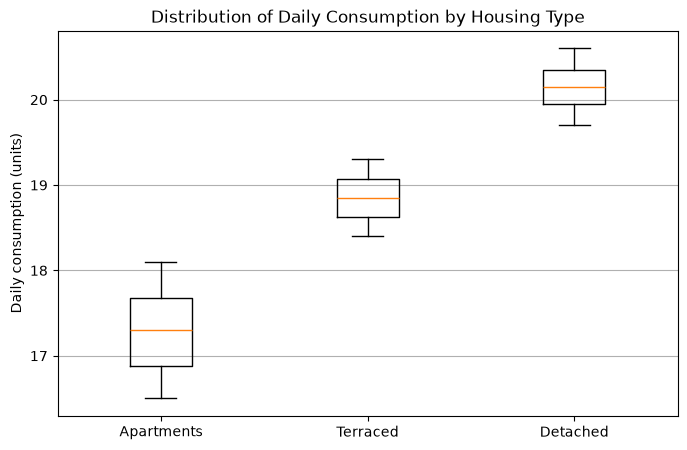

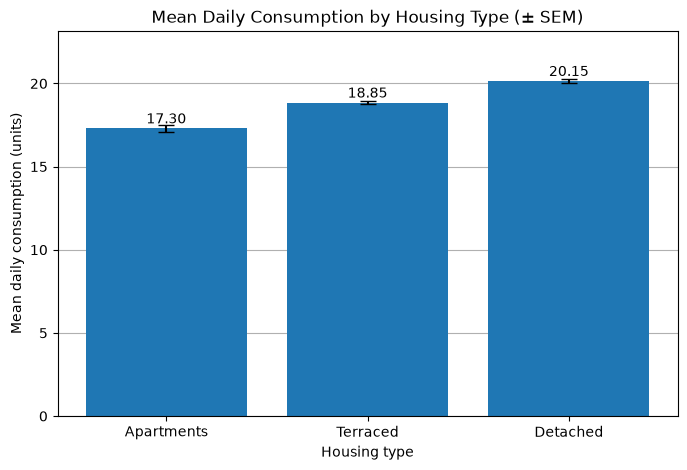

In [12]:
# 5. Visualisation - boxplot of consumption distribution by housing type
plt.figure(figsize=(8,5))
plt.boxplot([apartments, terraced, detached], tick_labels=labels)
plt.ylabel("Daily consumption (units)")
plt.title("Distribution of Daily Consumption by Housing Type")
plt.grid(axis='y')
plt.gca().set_axisbelow(True)
plt.show()

# 6. Visualisation - bar chart of group means with standard error bars
sems = [g.std(ddof=1) / np.sqrt(len(g)) for g in groups]

plt.figure(figsize=(8,5))
plt.bar(labels, means, yerr=sems, capsize=6, color='tab:blue')
for i in range(len(labels)):
    plt.text(i, means[i] + 0.3, f"{means[i]:.2f}", ha='center')
plt.xlabel("Housing type")
plt.ylabel("Mean daily consumption (units)")
plt.title("Mean Daily Consumption by Housing Type (\u00b1 SEM)")
plt.grid(axis='y')
plt.gca().set_axisbelow(True)
plt.ylim(0, max(means) + 3)
plt.show()